In [45]:
import json
import pandas as pd
from pathlib import Path
from xgboost import XGBRegressor

model = XGBRegressor()

# Path can't open file
model.load_model("/Users/chloekentebe/enerstasis-electricity-forecaster/xgboost_model/best_xgboost_model_j6.json")
with open("/Users/chloekentebe/enerstasis-electricity-forecaster/xgboost_model/feature_columns_j6.json", "r") as f:
    feature_columns = json.load(f)

In [46]:
analysis = pd.read_csv("/Users/chloekentebe/enerstasis-electricity-forecaster/processed_data/main_dataset.csv")
sample = analysis[feature_columns].iloc[[88000]] 
prediction = model.predict(sample)
print(prediction)

[20060.467]


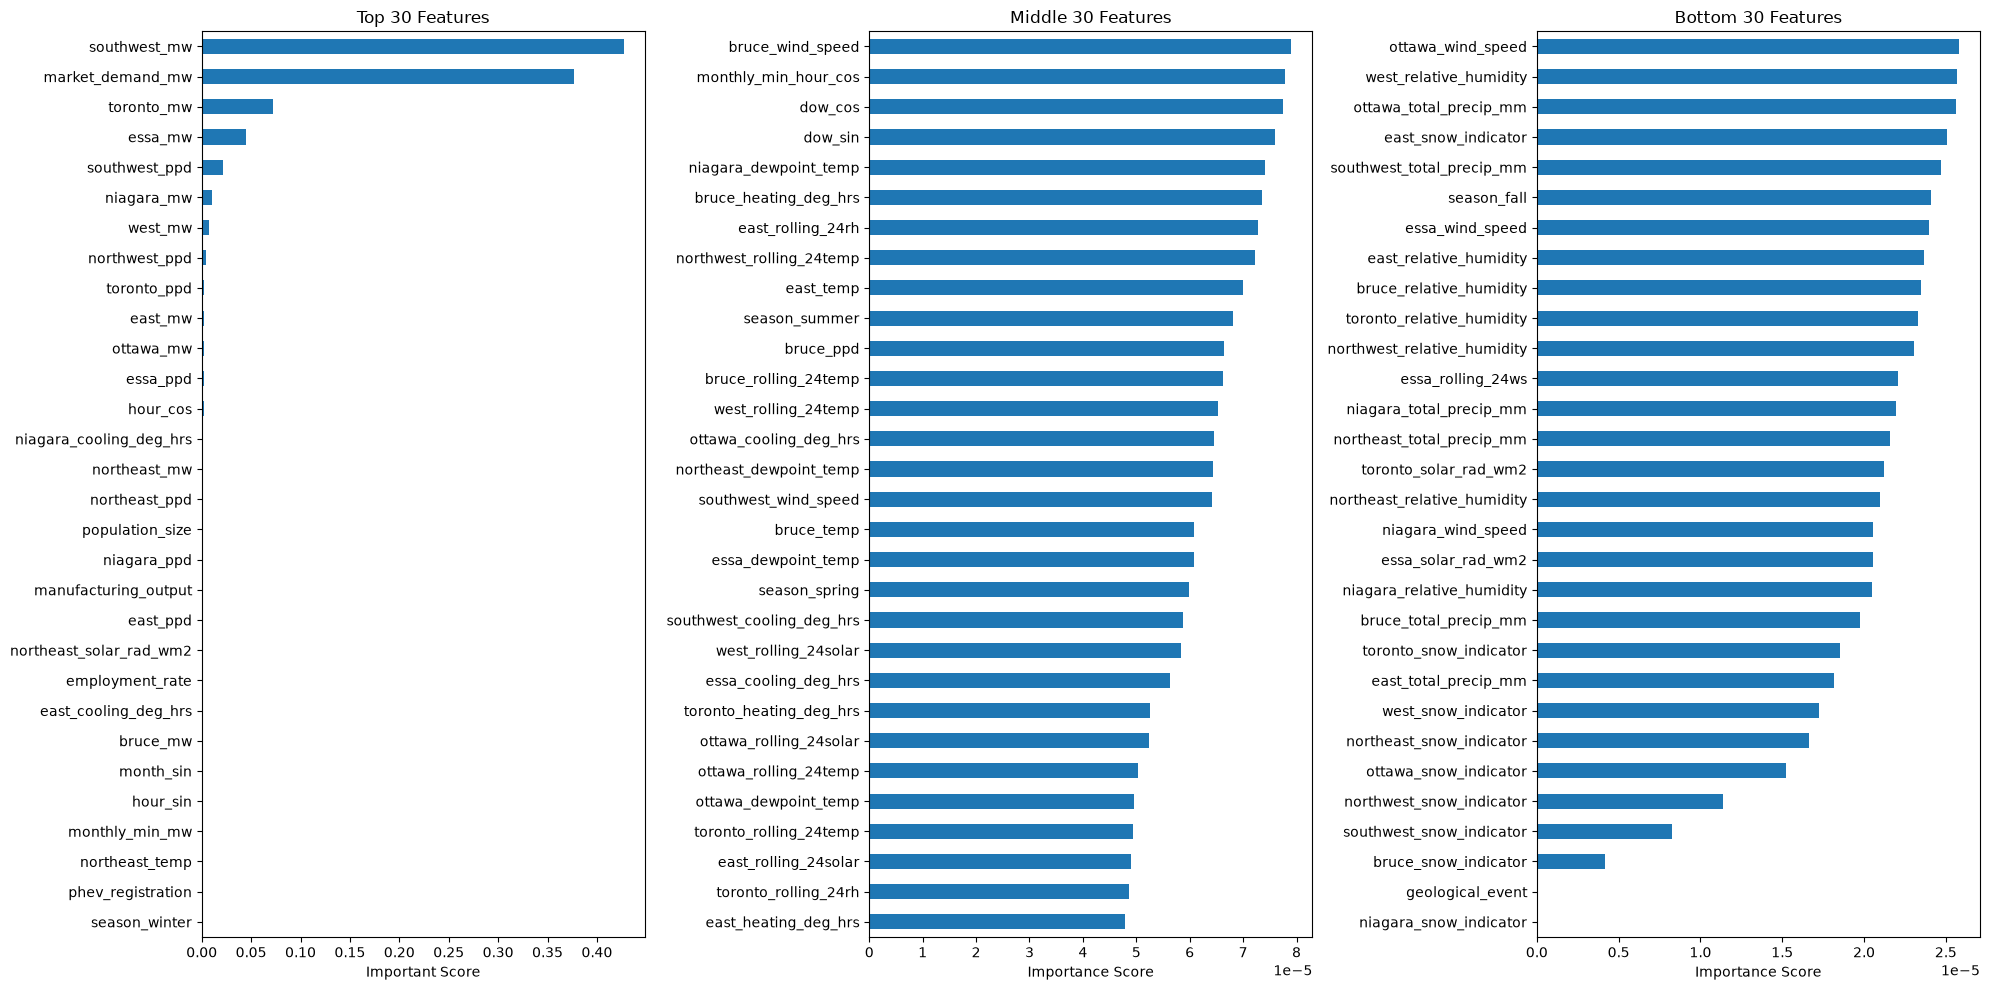

In [47]:
import matplotlib.pyplot as plt
important_metrics = pd.Series(model.feature_importances_, index=feature_columns)
im_ordered = important_metrics.sort_values(ascending=False)
num_features = len(im_ordered)
split_size = num_features // 3 # integer divide

top_30 = min(30, split_size)
top_feats = im_ordered.head(top_30)
mid_feats = im_ordered.iloc[split_size:split_size+top_30]
bottom_feats = im_ordered.tail(top_30)

figure, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 10), sharex=False)
plt.subplots_adjust(wspace=0.5)

top_feats.plot(kind="barh", ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_title("Top 30 Features")
axes[0].set_xlabel("Important Score")

mid_feats.plot(kind="barh", ax=axes[1])
axes[1].invert_yaxis()
axes[1].set_title("Middle 30 Features")
axes[1].set_xlabel("Importance Score")

bottom_feats.plot(kind="barh", ax=axes[2])
axes[2].invert_yaxis()
axes[2].set_title("Bottom 30 Features")
axes[2].set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [48]:
cum_importance = im_ordered.cumsum()
# FIND THE NUMBER OF FEATURES DOING 99% OF WORK (contributing to prediction)
req_features = (cum_importance <= 0.99).sum() + 1

print(req_features)

36


In [49]:
top_features = im_ordered[cum_importance <= 0.99]
if cum_importance.iloc[len(top_features) - 1] < 0.99:
    n_ind = len(top_features)
    if n_ind < len(im_ordered):
        top_features = im_ordered.iloc[:n_ind+1] #in case the last feature cross 99%
df = pd.DataFrame({
    "Feature Name": top_features.index,
    "Individual Importance": top_features.values,
    "Percentage Impact (%)": (top_features.values*100).round(4),
    "Cumulative Impact (%)": (cum_importance.iloc[:len(top_features)].values*100).round(4)
}).set_index("Feature Name")
pd.set_option("display.max_rows", None)
display(df)
print(len(df))

,Individual Importance,Percentage Impact (%),Cumulative Impact (%)
Feature Name,,,
southwest_mw,0.427161,42.716099,42.716099
market_demand_mw,0.377132,37.713200,80.429298
toronto_mw,0.071776,7.177600,87.606903
essa_mw,0.044439,4.443900,92.050797
southwest_ppd,0.021861,2.186100,94.236900
niagara_mw,0.010753,1.075300,95.312202
west_mw,0.007549,0.754900,96.067101
northwest_ppd,0.004388,0.438800,96.505898
toronto_ppd,0.002718,0.271800,96.777702


36


In [51]:
top_features = im_ordered[cum_importance <= 0.9]
if cum_importance.iloc[len(top_features) - 1] < 0.9:
    n_ind = len(top_features)
    if n_ind < len(im_ordered):
        top_features = im_ordered.iloc[:n_ind+1] #in case the last feature cross 99%
df_2 = pd.DataFrame({
    "Feature Name": top_features.index,
    "Individual Importance": top_features.values,
    "Percentage Impact (%)": (top_features.values*100).round(4),
    "Cumulative Impact (%)": (cum_importance.iloc[:len(top_features)].values*100).round(4)
}).set_index("Feature Name")
pd.set_option("display.max_rows", None)
display(df_2)
print(len(df_2))

,Individual Importance,Percentage Impact (%),Cumulative Impact (%)
Feature Name,,,
southwest_mw,0.427161,42.716099,42.716099
market_demand_mw,0.377132,37.713200,80.429298
toronto_mw,0.071776,7.177600,87.606903
essa_mw,0.044439,4.443900,92.050797


4
